In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
alt_ids = {
    ('f7cc6phw', r'FM-TF ($u_t(x|x_1)$, $\lambda=1$, $\sigma_\min = 1e-3$)'): {},
    ('0p7vmly7', r'FM-TF ($u_t(x|x_1)$, $\lambda=1$, $\sigma_\min = 1e-4$)'): {},
    ('m0crppjm', r'FM-TF ($u_t(x|x_1)$, $\lambda=2$, $\sigma_\min = 1e-4$)'): {},
    # ('rm36g01h', 'SM (EM,VE)'): {},
    # ('w3jrtijt', r'FM (Heun,OT,$\mathbb{E}[\sum]$)'): {},
    # ('xw2z2fze', r'FM (Heun,OT,$\sum\mathbb{E}$)'): {},

    # Easy
    # ('ekve4foi', r'FM-TF ($u_t(x|x_1)$, $\lambda=1$)'): {},
    # ('t3k8anow', 'SM (EM,VE)'): {},
    # ('0wlym20i', r'FM (Heun,OT,$\mathbb{E}[\sum]$)'): {},
    # ('cy4b0mmq', r'FM (Heun,OT,$\sum\mathbb{E}$)'): {},
}
label_to_alt_id = dict(map(reversed, alt_ids))
assert len(alt_ids) == len(label_to_alt_id), "Do two alt_id's have the same plot label?"

In [4]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('f7cc6phw', 'FM-TF ($u_t(x|x_1)$, $\\lambda=1$, $\\sigma_\\min = 1e-3$)'): {'cfg': Conf(root_dir='/home/sci/ttransue/GitHub/Data-Assimilation-Flow-Matching',
                                                                                          out_dir='/home/sci/ttransue/out/dafm',
                                                                                          run_subdir='runs',
                                                                                          prediction_filename='trajectories.parquet',
                                                                                          device='cuda',
                                                                                          alt_id='f7cc6phw',
                                                                                          rng_seed=2376999025,
                                                                                          fit=True,
                                           

In [5]:
for v in cfgs.values():
    v['trajectories'] = pd.read_parquet(v['cfg'].run_dir/v['cfg'].prediction_filename)

In [6]:
dim = 1
for v in cfgs.values():
    v['trajectories'][f'predicted_state_mean_{dim}'] = v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.contains(f'^predicted_state_[0-9]+_dim_{dim}$')]].mean(axis=1)

In [7]:

columns = v['trajectories'].columns
df_line = (
    pd.concat([
        v['trajectories'] for v in cfgs.values()
    ], keys=[k[1] for k in cfgs], names=['Model'])
    .reset_index()
    .melt(id_vars=['Model', 'times'], var_name='StateAndDim', value_name='State', value_vars=columns[
          (columns == f'predicted_state_mean_{dim}')
          | (columns == f'true_state_dim_{dim}')
    ])
    .rename(columns={'times': 'Time'})
)

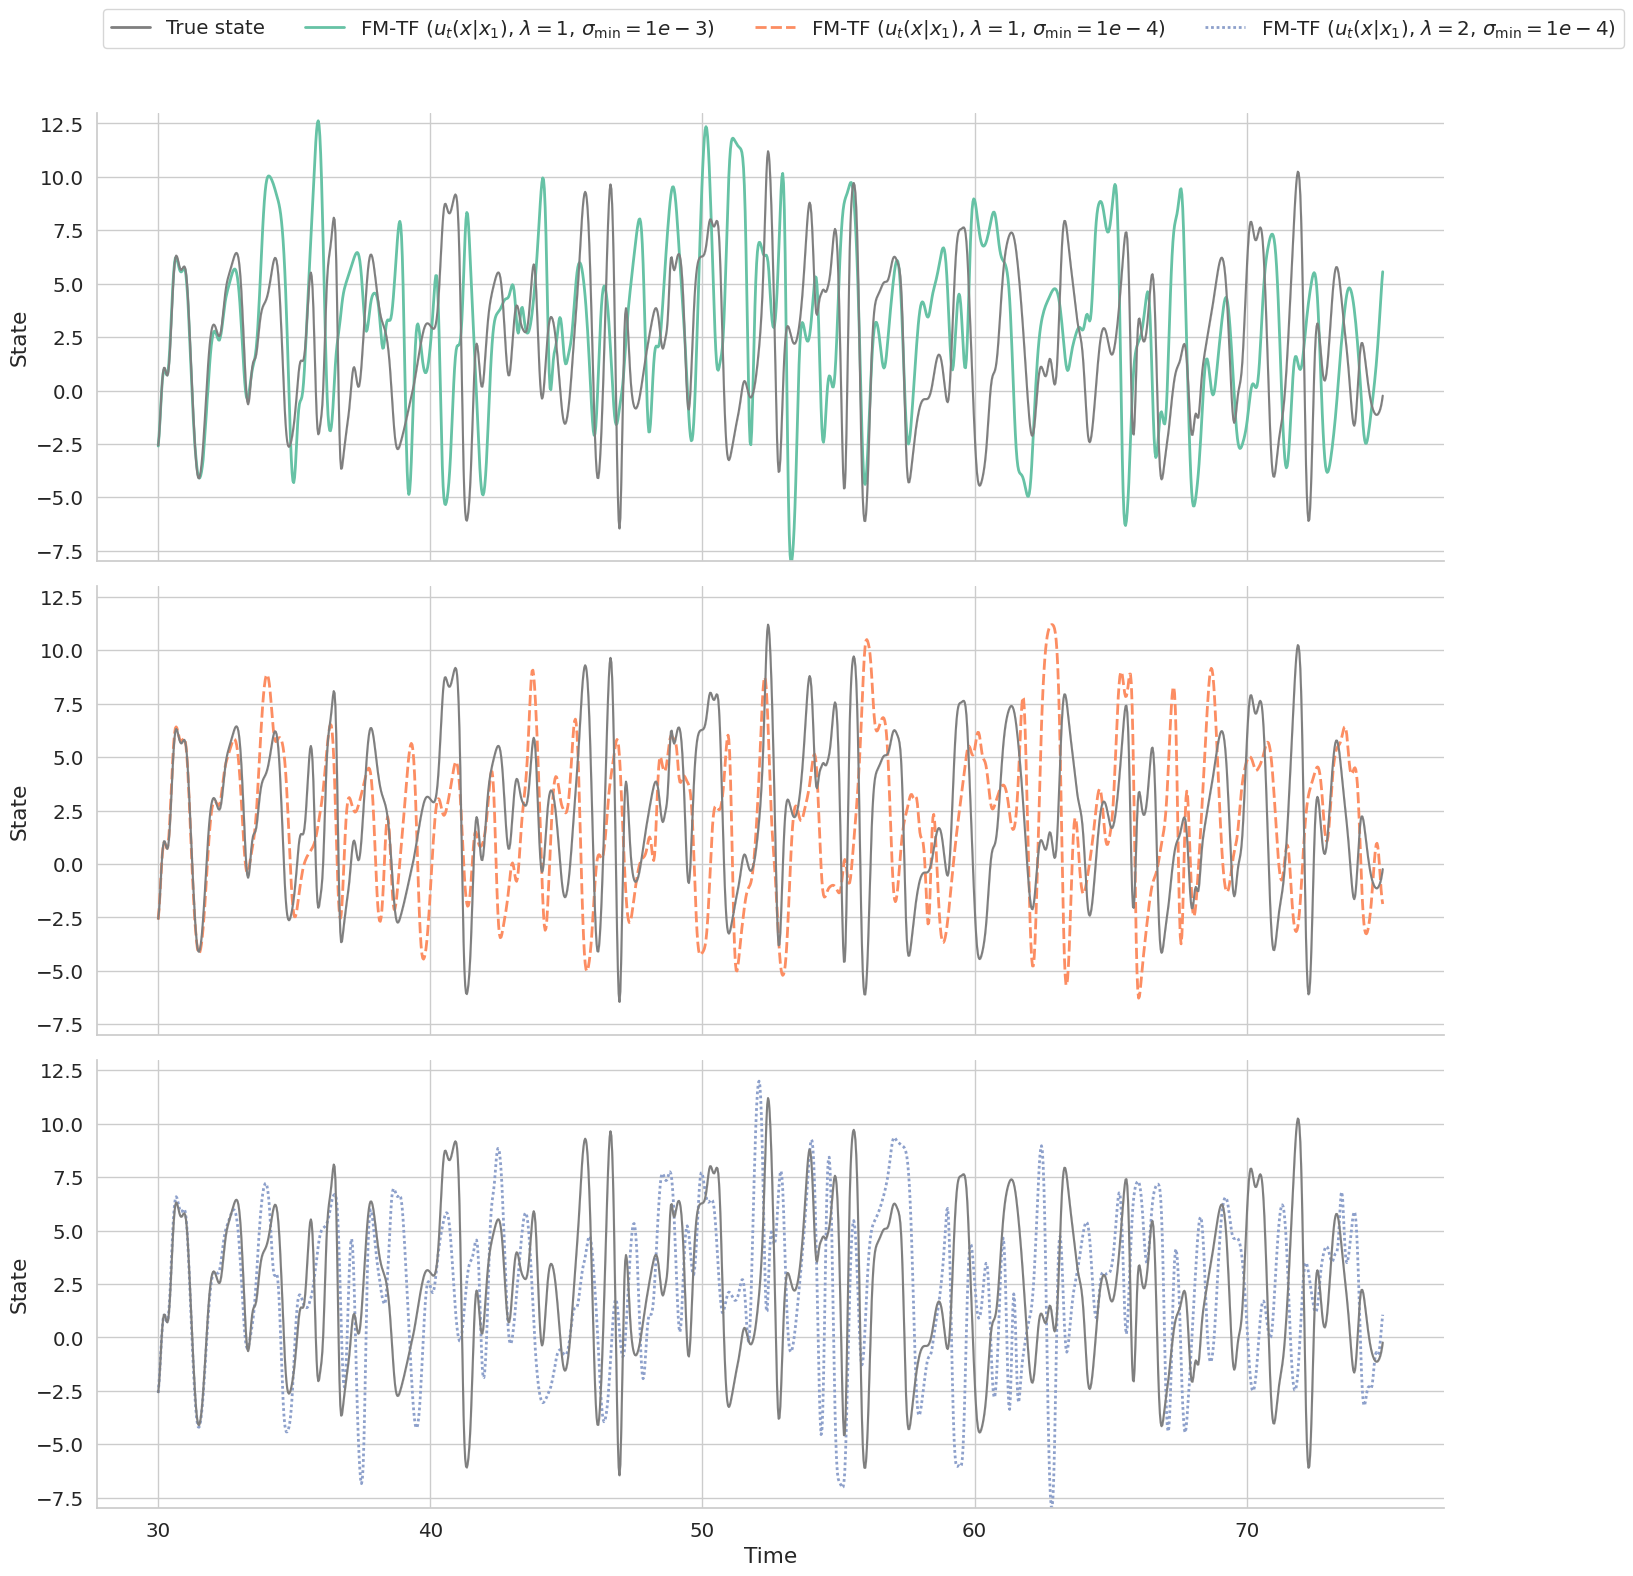

In [13]:
columns = v['trajectories'].columns
df_line = (
    pd.concat([
        v['trajectories'] for v in cfgs.values()
    ], keys=[k[1] for k in cfgs], names=['Model'])
    .reset_index()
    .melt(id_vars=['Model', 'times'], var_name='StateAndDim', value_name='State', value_vars=columns[
          (columns == f'predicted_state_mean_{dim}')
          | (columns == f'true_state_dim_{dim}')
    ])
    .rename(columns={'times': 'Time'})
)
line_to_plot = ('true_state_dim_', 'True state')
plot = (
    sns.relplot(
        data=df_line[df_line['StateAndDim'].str.startswith('predicted_state_mean_')],
        kind='line',
        x='Time',
        y='State',
        row='Model',
        hue='Model',
        style='Model',
        hue_order=[line_to_plot[1], *df_line['Model'].unique()],
        palette=['tab:gray', *sns.color_palette()[:len(df_line['Model'].unique())]],
        # markers=True,
        aspect=3,
        linewidth=2,
        # hue_order=['true_state', 'predicted_state_mean'],
    )
    .set_titles('')
    .set(ylim=(-8, 13))
)
plot.map(
    sns.lineplot,
    data=df_line[df_line['StateAndDim'].str.startswith(line_to_plot[0])],
    x='Time',
    y='State',
    color='tab:gray',
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=min(len(df_line['Model'].unique()), 3) + 1,
    title='',
    bbox_to_anchor=(.455, 1.06),
    frameon=True,
    fancybox=True,
)

In [9]:
# df = df_line[~df_line.isna().any(axis=1)]
# print('RMSE')
# print(df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).pow(2).mean().pow(1/2).to_latex())
# print('MAE')
# print(df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).abs().mean())
# (df.T - df['True state']).T.pow(2).sum()

In [10]:
plots.save_all_subfigures(plot, 'Predictions', renaming=label_to_alt_id)

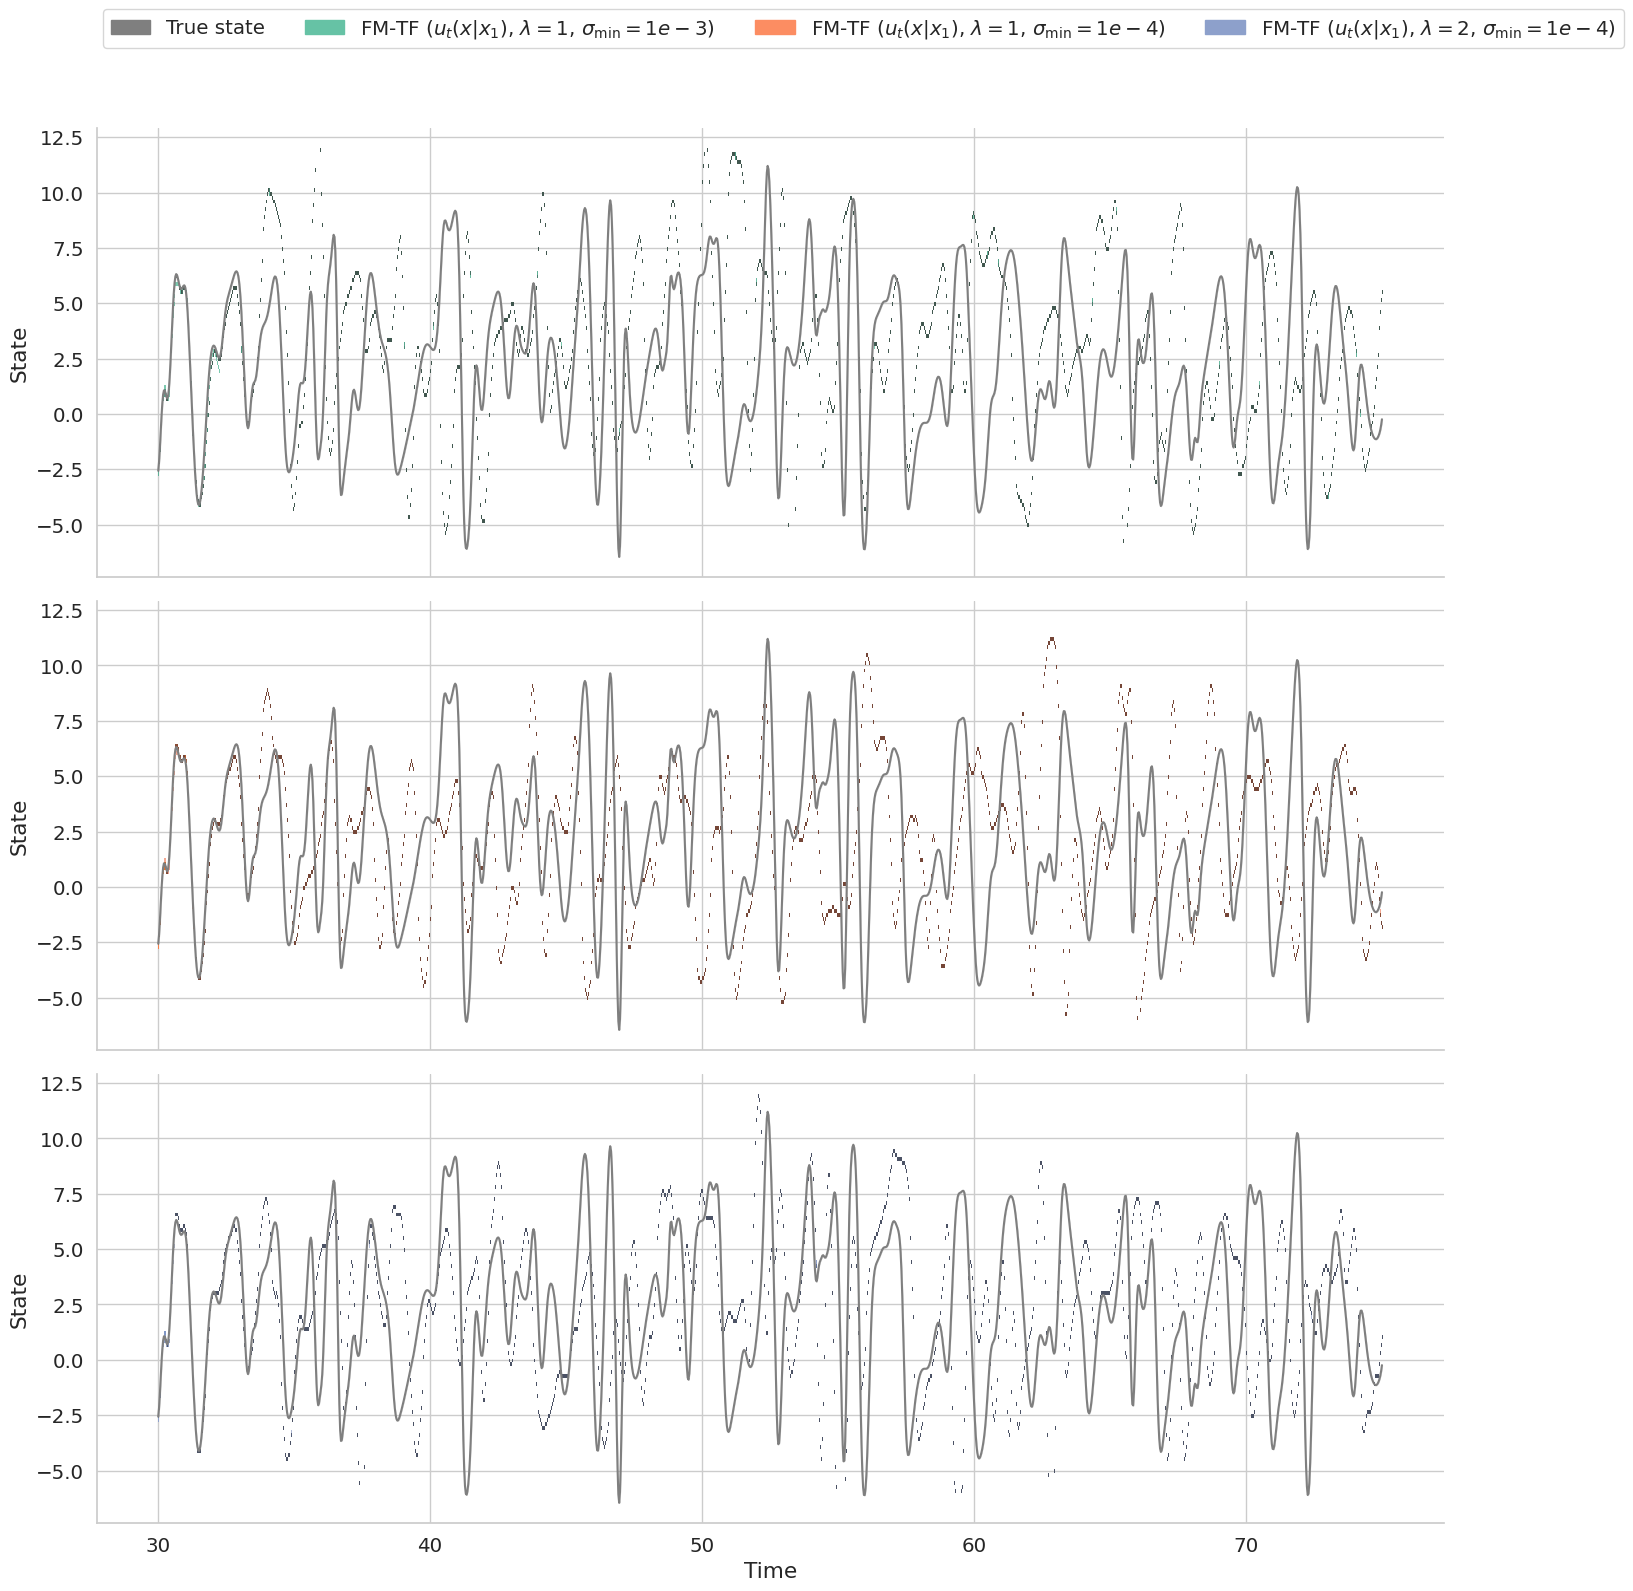

In [11]:
df_hist = (
    pd.concat([
        v['trajectories'] for v in cfgs.values()
    ], keys=[k[1] for k in cfgs], names=['Model'])
    .reset_index()
    .melt(id_vars=['Model', 'times'], var_name='Source', value_name='State', value_vars=v['trajectories'].columns[v['trajectories'].columns.str.contains(f'^predicted_state_[0-9]+_dim_{dim}$')])
    .rename(columns={'times': 'Time'})
)#.melt(id_vars=['Time'], var_name='Source', value_name='State')
line_to_plot = 'True state'
plot = (
    sns.displot(
        data=df_hist,
        x='Time',
        y='State',
        row='Model',
        hue='Model',
        hue_order=[line_to_plot, *df_hist['Model'].unique()],
        palette=['tab:gray', *sns.color_palette()[:len(df_hist['Model'].unique())]],
        bins=(v['trajectories']['times'], 101),
        binwidth=(v['trajectories']['times'].diff().iloc[-1], None),
        aspect=3,
        binrange=(None, (-6, 12)),
    )
    .set_titles('')
    # .set(xticks=[])
)
plot.map(
    sns.lineplot,
    data=df_line[df_line['StateAndDim'].str.startswith('true_state_dim_')],
    x='Time',
    y='State',
    color='tab:gray',
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=len(df_hist['Model'].unique()) + 1,
    title='',
    bbox_to_anchor=(.455, 1.07),
    frameon=True,
    fancybox=True,
)

In [12]:
plots.save_all_subfigures(plot, 'PredictedStateHistogram', renaming=label_to_alt_id)